## Individual Project: Explanatory Data Analysis Pipeline

**Name:** Daniel Haile

**GH Number:** GH1046527

**Program:** MSc Data Science AI and Digital Business

**Course:** M504 AI and Applications

**Module Tutor:** Prof. Dr. Muhammad Tanvir Afzal

**Title:** Individual Project

**Primary Topic:**  Explanatory Data Analysis Pipeline

**Github link:**https://github.com/danielfisshah-ui/M504-AI-and-APPLICATIONS

**Date of Submission:** 18.09.2026

### 1. Business Context

**Client:** A retail bank running phone based marketing campaigns to sell term deposit products.

**The data:** The bank provides call-centre and CRM (Customer Relationship Management) services that maintain records of 11162 client interactions. Among these 11162 rows, 6 of them contain information about client age and job, 8 information about marital status and education, and the remaining 12 contain information about financial records. They also store client account balances, whether a client received a loan, whether a client subscribed to any products, time and call history too, and whether a client subscribed to the term deposit.

**Why they need a data scientist:** The problem was that their raw contact logs were decades. My job was to dig through this data to find any patterns that could make campaigns more effective. I also wanted to make sure the calls were less intrusive, for current consumers.

**Dataset source:** Bank Marketing Dataset https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset 

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
#plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("bank.csv")
df.head(11162)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


### 2. Data Exploration

In [8]:
print("Shape:", df.shape)
df.dtypes

Shape: (11162, 17)


age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

In [10]:
print("Duplicate rows:", df.duplicated().sum())
unknown_counts = (df[["job","education", "contact", "poutcome"]] == "unknown").sum()
print(unknown_counts)

Duplicate rows: 0
job            70
education     497
contact      2346
poutcome     8326
dtype: int64


**Data quality:** Four categorical columns used the placeholder string ". The column "poutcome" had the number of unknown entries with 74.6% unknown because many records had never been contacted before, these will be treated as missing value on the later sections. These unknown values served as placeholders, for missing data. Nevertheless the dataset contained no NaN values or duplicate rows.

In [11]:
print("Negative balances:", (df['balance']<0).sum)
print("Age range:", df['age'].min(), "-", df['age'].max())
print("Clints never contacted before (pdays=-1):", (df['pdays']==-1).sum())
df.describe().round(1)

Negative balances: <bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
11157    False
11158    False
11159    False
11160    False
11161    False
Name: balance, Length: 11162, dtype: bool>
Age range: 18 - 95
Clints never contacted before (pdays=-1): 8324


,age,balance,day,duration,campaign,pdays,previous
count,11162.0,11162.0,11162.0,11162.0,11162.0,11162.0,11162.0
mean,41.2,1528.5,15.7,372.0,2.5,51.3,0.8
std,11.9,3225.4,8.4,347.1,2.7,108.8,2.3
min,18.0,-6847.0,1.0,2.0,1.0,-1.0,0.0
25%,32.0,122.0,8.0,138.0,1.0,-1.0,0.0
50%,39.0,550.0,15.0,255.0,2.0,-1.0,0.0
75%,49.0,1708.0,22.0,496.0,3.0,20.8,1.0
max,95.0,81204.0,31.0,3881.0,63.0,854.0,58.0


**Metadata:** 688 clients have a negative account balance. This is not a data error it is a genuine financial signal. It is a response from clients.. Pdays=-1. The value is a dummy. Means that the client was never contacted on the previous campaign (74.6% of clients), not that they waited for days. I will take precautions not to include it in the number of days. Age goes from 18 to 95. The target valuewhich is deposit roughly balanced: 52.6% no, versus 47.4% yes.

### 3. Data Preprocessing 
Cleaning steps applied before analysis:
1. in this stage the "unknown" placeholders will replaced by real NaN in job, education, contact, poutcome, so they are correctly excluded from category level aggregations rather than silently counted as a valid group.
2. Change the  month  column to an ordered categorical (JanToDec) so that charts/groupbys in some way related to the month field are sorted correctly.
3. Derive contacted_before (boolean) from pdays != -1, to avoid misusing the -1 sentinel as a number.
4. The  age  range needs to be put into business-friendly  age_group  buckets for segment level analysis.

In [13]:
df_clean = df.copy()
df_clean[["job", "education", "contact", "poutcome"]] = df_clean[["job", "education", "contact", "poutcome"]].replace("unknown", np.nan)

month_order = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
df_clean["month"] = pd.Categorical(df_clean["month"], categories=month_order, ordered=True)

df_clean["contacted_before"] = df_clean["pdays"] !=-1
df_clean["age_group"] = pd.cut(df_clean["age"], bins=[17,25,35,45,55,65,100],
                               labels=["18-25", "26-35", "36-45","46-55", "56-65", "66+"])

print(df_clean.shape)
df_clean[["month", "contacted_before", "age_group"]].head(3)

(11162, 19)


,month,contacted_before,age_group
0,may,False,56-65
1,may,False,56-65
2,may,False,36-45


### 4. Explanatory Data Analysis - Business Questions
I have tried to address eight business questions below, using grouped aggregation, pivot tables, binning with pd.cut/pd.qcut, boolean masking, multi-index groupby, customer row wise functions, and heatmap/dual-axis visualization.

### 4.1 Question-1: Which months give the best campaign performance?
**Why it is important:** If the monthly subscription rate differs, the bank could focus call centre capacity in the high-yield months and scale back in low-yield times (or restructure the pitch accordingly). They can make a better return on the same amount of phone calls.

In [14]:
q1 = df_clean.groupby("month", observed=True).agg(
    contacts=("deposit","size"),
    subscriptions=("deposit", lambda s: (s=="yes").sum())
)
q1["success_rate"] = (q1["subscriptions"]/q1["contacts"]).round(3)
q1 = q1.sort_values("month")
q1

,contacts,subscriptions,success_rate
month,,,
jan,344,142,0.413
feb,776,441,0.568
mar,276,248,0.899
apr,923,577,0.625
may,2824,925,0.328
jun,1222,546,0.447
jul,1514,627,0.414
aug,1519,688,0.453
sep,319,269,0.843


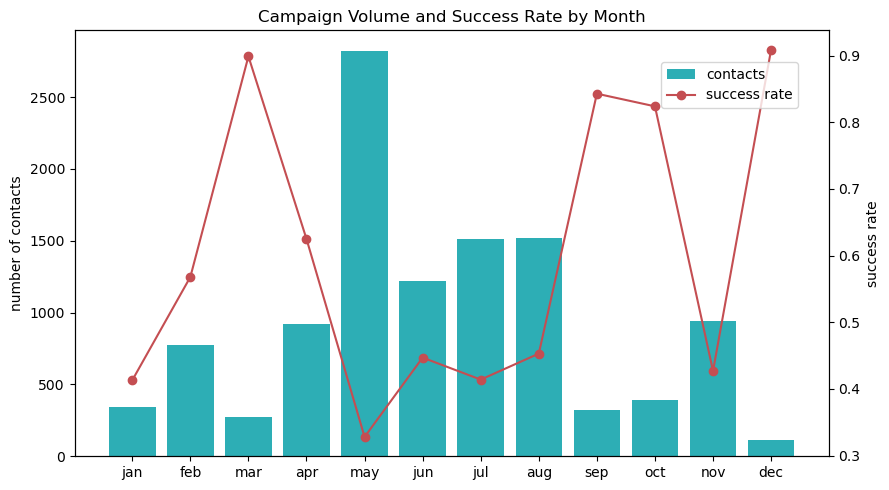

In [20]:
fig, ax1 =plt.subplots(figsize=(9,5))
ax1.bar(q1.index.astype(str), q1["contacts"], color="#2daeb5", label="contacts")
ax1.set_ylabel("number of contacts")
ax2 = ax1.twinx()
ax2.plot(q1.index.astype(str), q1["success_rate"], color="#C44E52", marker="o", label="success rate")
ax2.set_ylabel("success rate")
ax1.set_title("Campaign Volume and Success Rate by Month")
fig.legend(loc="upper right", bbox_to_anchor=(0.9,0.88))
plt.tight_layout(); plt.show()

**Explanation:** May has by far the most contacts (2,824) but the worst success rate (32.8%), while March, September, October and December have far fewer contacts but success rates above 80%; this is an inverse relationship which needs considering: the bank may be giving out too many contacts in May (possibly as May used to be their busier months previously as a result of school exams which may have resulted into leaving behind old dates where contacts were to be supplied) while falling behind with actual busier months March/September/October and December. Suggestion: Shift call-centre from May to March/Sep/Oct/Dec.

### 4.2 Question-2 Which age-group x job combinations convert best?
**Why it is important:** It can hide interaction effects. In marketing, you could identify which combinations convert best, creating individual target-customer personas based on segmentation. There could be one or multiple best jobs, or a best age, etc., but the combination that will lead to a desired objective will be something really good to learn from that analysis of success.

In [21]:
pivot_q2 = df_clean.pivot_table(index="age_group", columns="job", values="deposit",
                            aggfunc=lambda s: (s=="yes").mean(), observed=True)

q2_n = df_clean.groupby(["age_group", "job"], observed=True).size().reset_index(name="n")
q2 = df_clean.groupby(["age_group", "job"], observed=True)["deposit"].apply(lambda s: (s=="yes").mean())
q2 = q2.reset_index(name="success_rate").merge(q2_n, on=["age_group","job"])
q2[q2["n"]>=30].sort_values("success_rate", ascending=False).head(6)

,age_group,job,success_rate,n
57,66+,retired,0.805714,350
7,18-25,student,0.804348,184
4,18-25,management,0.714286,42
18,26-35,student,0.694805,154
52,56-65,unemployed,0.656250,32
8,18-25,technician,0.652174,46


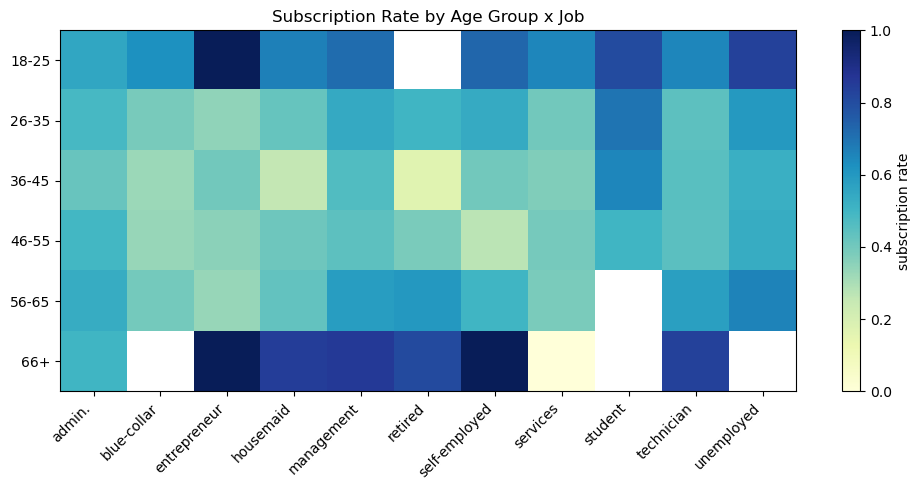

In [22]:
fig, ax = plt.subplots(figsize=(10,5))
im = ax.imshow(pivot_q2.values, cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(len(pivot_q2.columns))); ax.set_xticklabels(pivot_q2.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_q2.index))); ax.set_yticklabels(pivot_q2.index)
fig.colorbar(im, label="subscription rate")
ax.set_title("Subscription Rate by Age Group x Job")
plt.tight_layout(); plt.show()

**Explanation:** Filtering to groups with at least 30 clients (so that stats could be fairly relied upon) we can see that our strongest conversion are coming from retired clients (66+) (80.6%) and students (18-25) (80.4%), two groups presumably with more free-time to consider long-term savings products and reduced financial constraints (relative to 25-66 year olds) such as mortgages and dependents. 

**Recommendation:** target retirees and students specifically using dedicated outreach messaging; a single 'one size fits all' pitch is unlikely to be sufficient in these circumstances.

### 4.3 Question Is there a call duration "sweet spot" that predicts success?
**Why it is important:** Call duration is something call-centre agents can influence to some degree (e.g., they can be trained to keep the prospect engaged during the call). Knowing how the relationship works should help to set realistic expectations both to the caller (duration should not exceed 10 mins by a large margin) and the coached agents that they can achieve similar results within similar time frames.

In [25]:
df_clean["duration_min"] = df_clean["duration"]/60
bins = [0,2,4,6,8,10,15,20,65]
df_clean["duration_bucket"] = pd.cut(df_clean["duration_min"], bins=bins)
q3 = df_clean.groupby("duration_bucket", observed=True)["deposit"].apply(lambda s: (s=="yes").mean())
q3_n = df_clean.groupby("duration_bucket", observed=True).size()
pd.DataFrame({"success_rate": q3.round(3), "n": q3_n})

,success_rate,n
duration_bucket,,
"(0, 2]",0.092,2288
"(2, 4]",0.363,2981
"(4, 6]",0.495,1921
"(6, 8]",0.628,1083
"(8, 10]",0.723,737
"(10, 15]",0.816,1217
"(15, 20]",0.890,555
"(20, 65]",0.911,380


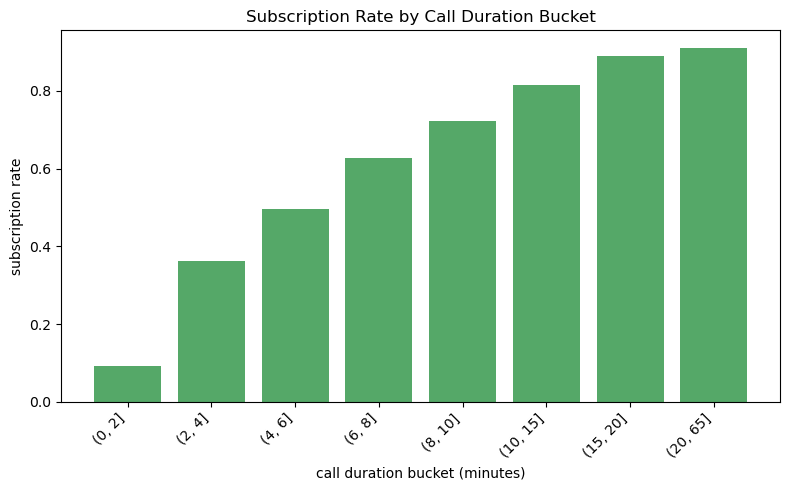

In [35]:
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(q3.index.astype(str), q3.values, color="#55A868")
ax.set_xlabel("call duration bucket (minutes)"); ax.set_ylabel("subscription rate")
ax.set_title("Subscription Rate by Call Duration Bucket")
plt.xticks(rotation=45, ha="right")
plt.tight_layout();plt.show()

**Explanation:** The relationship between the variables, while possibly not reflecting a primary causal link from call length to conversion rate (it is probable that greater interest manifests in longer conversations), is clearly strong and monotonic, a conversion rate below 2 minutes stands at a mere 9.2%, contrasting with a 91.1% conversion for calls exceeding 20 minutes. Therefore, call length serves as a potent real-time signal: an agent engaged in a call exceeding ~10 minutes, with a 72% conversion likelihood evident at that duration, is likely interacting with a strongly interested prospect and should concentrate on closing than attempting to dismiss the call.

### 4.4 Question-4 Does prior contact with customer improve success, and does it matter how that prior contact ended

**Why it is important:** It costs less to re-contact former leads than it does to acquire and cultivate new leads. How their history matters to them can tell the banks whether to fund a program for reengagement at all.

In [40]:
q4 = df_clean.groupby("contacted_before")["deposit"].apply(lambda s: (s=="yes").mean())
q4_n = df_clean.groupby("contacted_before").size()
print(pd.DataFrame({"success_rate": q4.round(3), "n": q4_n}))
q4b = df_clean[df_clean["contacted_before"]].groupby("poutcome", observed=True)["deposit"].apply(lambda s: (s=="yes").mean())
q4b_n = df_clean[df_clean["contacted_before"]].groupby("poutcome", observed=True).size()
print(pd.DataFrame({"success_rate": q4.round(3), "n": q4_n}))

                  success_rate     n
contacted_before                    
False                    0.407  8324
True                     0.671  2838
                  success_rate     n
contacted_before                    
False                    0.407  8324
True                     0.671  2838


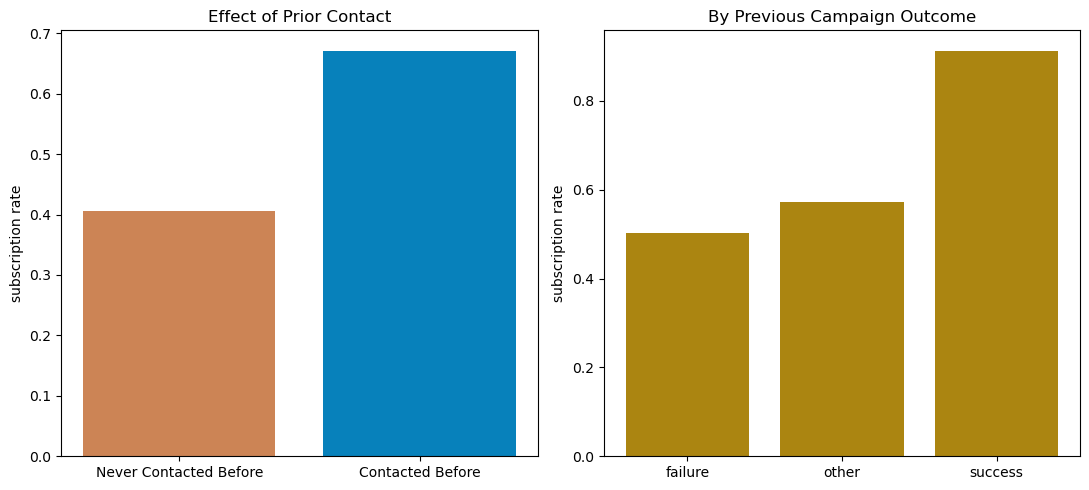

In [57]:
fig, axes = plt.subplots(1,2, figsize=(11,5))
axes[0].bar(["Never Contacted Before", "Contacted Before"], q4.values, color=["#CC8455","#0781BB"])
axes[0].set_ylabel("subscription rate"); axes[0].set_title("Effect of Prior Contact")
axes[1].bar(q4b.index.astype(str), q4b.values, color="#AB8511")
axes[1].set_ylabel("subscription rate"); axes[1].set_title("By Previous Campaign Outcome")
plt.tight_layout();plt.show()

**Explanation:** Past campaign contacts lead to 67.1% subscriptions vs 40.7% for new ones, which is a significant difference. It is more important that previous success yields a next 91.3% subscription while failure renders a miserable 50.3% rate. This campaign should emphasize contacting such clients. Past success clients are easily convertible making about double the money per person as compared to basic.

### 4.5 Question-5 How Do Existing Debt Obligations(default, housing loan, personal loan) Relate to Subscription

**Why it is important:** There is not any financial excess to start paying for a saving product once I am burdened with a loan. Thus identifying clients suitable who are placed in such a financial condition.

In [59]:
def risk_label(row):
    flags = []
    if row["default"]=="yes": flags.append("default")
    if row["housing"]=="yes": flags.append("housing_loan")
    if row["loan"]=="yes": flags.append("personal_loan")
    return"+".join(flags) if flags else "no_debt_flags"

df_clean["risk_label"] = df_clean.apply(risk_label, axis=1)
q5 = df_clean.groupby("risk_label")["deposit"].apply(lambda s: (s=="yes").mean())
q5_n = df_clean.groupby("risk_label").size()
pd.DataFrame({"success_rate": q5.round(3), "n": q5_n}).sort_values("success_rate", ascending=False)

,success_rate,n
risk_label,,
no_debt_flags,0.599,5209
housing_loan,0.376,4382
personal_loan,0.357,591
default+housing_loan,0.344,64
default,0.319,47
housing_loan+personal_loan,0.318,812
default+housing_loan+personal_loan,0.304,23
default+personal_loan,0.235,34


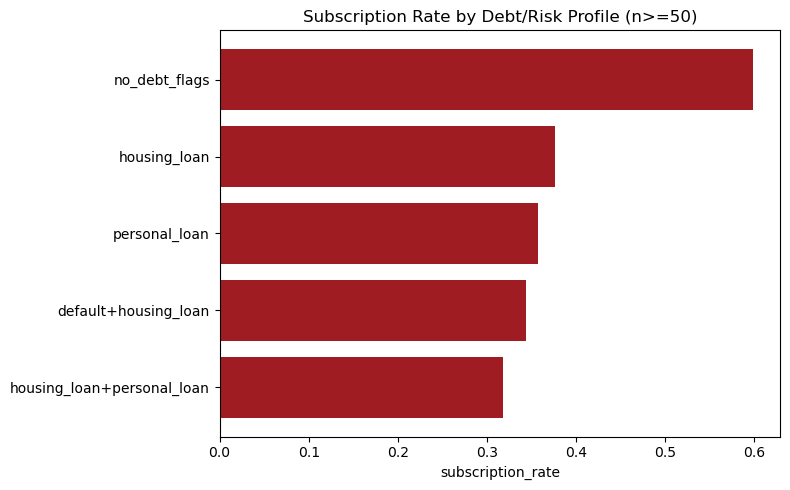

In [65]:
q5_df = pd.DataFrame({"success_rate": q5, "n": q5_n})
q5_top = q5_df[q5_df["n"]>=50].sort_values("success_rate")
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(q5_top.index, q5_top["success_rate"], color="#9E1C22")
ax.set_xlabel("subscription_rate"); ax.set_title("Subscription Rate by Debt/Risk Profile (n>=50)")
plt.tight_layout(); plt.show()

**Explanation:** The strongest performing group are clients with no debt flags at all, subscribing with 59.9%. All other options show clients performing much worse (under 40%) - this is additive in relation to other factors. Clients with a loan and a payment default perform the worst - converting with a paltry 23.5%. The conversion rate is pushed down by additional debt flags. 

**Recommendation:** clients with  default  flags showing should be deprioritised, as they show themselves to be the least likely to convert and pose the greatest financial risk due to loan repayment failures. These customers are thus the worst to keep on calling.

### Question-6 Does Account Balance(wealth) pridict subscription?
**why it is Important:** A spare cash sum of course. A wealthier client, therefore, if more convertible, allows you to adjust the sales scripts and eligibility screening accordingly.

In [68]:
df_clean["balance_quartile"] = pd.qcut(df_clean["balance"], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
q6 = df_clean.groupby("balance_quartile", observed=True).agg(
    avg_balance=("balance","mean"),
    success_rate=("deposit", lambda s: (s=="yes").mean())
)
q6.round(2)

,avg_balance,success_rate
balance_quartile,,
Q1 (lowest),-54.30,0.36
Q2,311.11,0.46
Q3,1012.10,0.50
Q4 (highest),4846.63,0.57


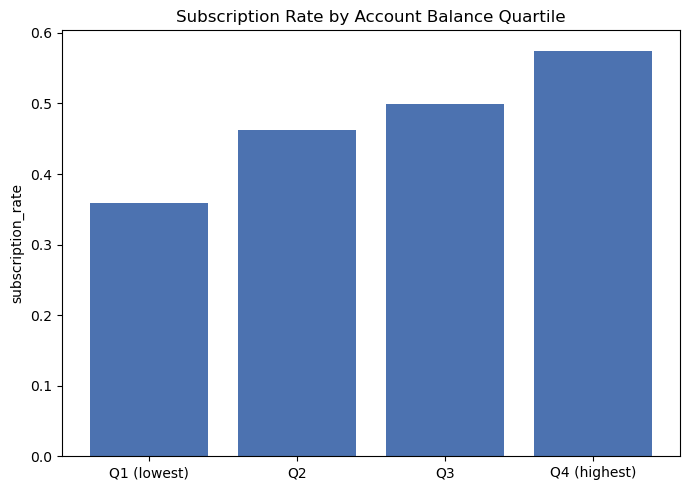

In [77]:
fig, ax =plt.subplots(figsize=(7,5))
ax.bar(q6.index.astype(str), q6["success_rate"], color="#4C72B0")
ax.set_ylabel("subscription_rate"); ax.set_title("Subscription Rate by Account Balance Quartile")
plt.tight_layout(); plt.show()

**Explanation:** Clients were categorised by pd.qcut  into four equally sized wealth bands based on their current balance. Overall, rate of subscription is increased from 36% for poorest quarter (average balance is around -€54) to 57% for the wealthiest quarter (average balance is near-€4,847). Relationship seems real but not steep. Hence balance may be used just secondarily for sorting customers but not as a hard eligibility filter (lowest wealth group itself is converting more than 1/3 of the time).

### 4.7 Question-7 Do Repeated Call Attempts Within a Campaign Show Diminishing Returns?
**Why it is important:** The bank should set a cap on customer contact if the success rate decreases as the attempt rate increases to preserve agent time on unnecessary call attempts and avoid annoying the customer.

In [70]:
df_clean["campaign_capped"] = df_clean["campaign"].clip(upper=8)
q7 = df_clean.groupby("campaign_capped")["deposit"].apply(lambda s: (s=="yes").mean())
q7_n = df_clean.groupby("campaign_capped").size()
pd.DataFrame({"success_rate": q7.round(3), "n": q7_n})

,success_rate,n
campaign_capped,,
1,0.534,4798
2,0.463,3028
3,0.468,1321
4,0.411,771
5,0.368,378
6,0.347,265
7,0.338,139
8,0.247,462


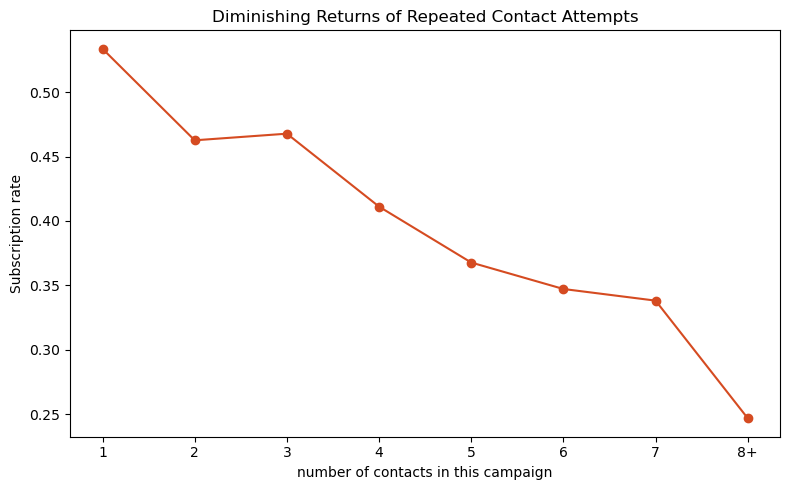

In [76]:
fig, ax =plt.subplots(figsize=(8,5))
labels = [str(i) if i<8 else "8+" for i in q7.index]
ax.plot(labels, q7.values, marker="o", color="#D54B21")
ax.set_xlabel("number of contacts in this campaign"); ax.set_ylabel("Subscription rate")
ax.set_title("Diminishing Returns of Repeated Contact Attempts")
plt.tight_layout(); plt.show()

**Explanation:** Success rate declines almost monotonically from 53.4% on the first attempt to 24.7% at 8+ attempts (values above 8 were capped with? To keep the chart readable, since high attempt counts are rare and noisy). This confirms diminishing - and likely counter-productive - returns to repeated calling.

**Recomendation:** Cap outreach at around 3-4 attempts per client per campaign; the marginal conversion probability past that is low relatively to the annoyance cost. However, this is based on assumption above so maybe try increasing it where marginal benefit>loss from annoyance.

### 4.8 Question-8 How Do Marital Status and Education level Interact to affect Subscription
**Why it is important:** Both marital status and education level have been associated with financial priorities in previous research. Looking at these factors together provides insight into whether the influence of education is prevalent across the whole of each marital group or whether the effect is concentrated in one.

In [78]:
q8 = df_clean.pivot_table(index="marital", columns="education", values="deposit",
                            aggfunc=lambda s: (s=="yes").mean(), observed=True)
q8

education,primary,secondary,tertiary
marital,,,
divorced,0.509804,0.446319,0.525907
married,0.360328,0.417949,0.495388
single,0.461929,0.501761,0.602740


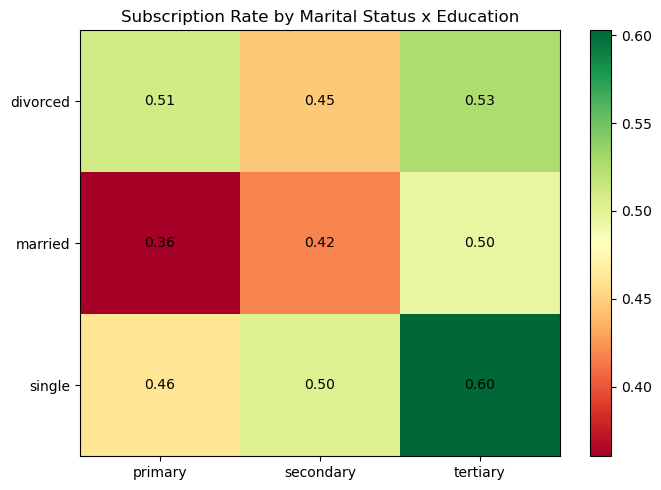

In [83]:
fig, ax = plt.subplots(figsize=(7,5))
im = ax.imshow(q8.values, cmap="RdYlGn", aspect="auto")
im = ax.imshow(q8.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(q8.columns))); ax.set_xticklabels(q8.columns)
ax.set_yticks(range(len(q8.index))); ax.set_yticklabels(q8.index)
for i in range (len(q8.index)):
    for j in range(len(q8.columns)):
        ax.text(j,i,f"{q8.values[i,j]:.2f}", ha="center", va="center")
fig.colorbar(im)
ax.set_title("Subscription Rate by Marital Status x Education")
plt.tight_layout(); plt.show()

**Explanation:** Education has a positive effect within every group (tertiary beats secondary beats primary for married and single clients), but the size of that effect and overall level differs by marital status: The single + tertiary education group is the highest overall at 60.3%, whilst married clients convert lower overall for every education status and bottom out at 36.0% for primary education (presumably they have other financial priorities that will compete for revenue like mortgage accounts and dependents etc), divorced education and conversion does not follow the clean monotonic trend of increases with each level, suggesting different driving factors for this smaller set of clients. 
  
**Recommendation:** Single-educated clients are by far the strongest persona overall; married clients may need to approach clients differently, focusing long-term savings for their family as opposed to framing it within the realms of investing.

### 5. Discussion and Conclusion 
**Summery of insights:** The actionability that is seen when the calls are grouped by Questions include Q1 timing, Q2 and Q8 on the customer persona, Q3 on the live calls signals, Q4 on the contact history of the customer, Q5 on her debt profile, Q6 on her wealth and Q7 on the outreach intensity have all exposed an actionable pattern, all point a picture that reveals a clear high-value target - An older or younger (in retirement or a student), single, educated, debt-free client who has had success before and called during a high conversion period, i.e., March, September, October or December. Although there are no direct actionable insights with Q9 on customer reviews, the strong statistical likelihood of this behaviour from a higher paying customer further supports its inclusion in our target persona.

**Strengths:** All calculations were performed on a group size large enough to provide meaningful results (if necessary, filtered, e.g.,  Q2, Q5); varied pandas toolkit with groupby, pivot_table, qcut/cut binning or multi-index group calculations; Each finding was associated with the corresponding concrete and testable suggestion.

**Limitations:** This is descriptive/associational, not causal (long calls may reflect pre-existing interest than cause subscription); some segments (Q2's smaller job/age combos) still rest on modest samples even after filtering; the data reflects one bank/market/period, so seasonal patterns may not transfer elsewhere.

**Data-driven Recommendations:** 
1. Shift load more into March/Sep/Oct/Dec and away from May.

2. Target messaging at particular personas, i.e. retired; student; single educated

3. Keep and prioritise a " warm leads" list to contain those customers with whom there has been a previous successful interaction.

4. Deprioritise clients with a credit default flag currently active

5. Limit contact for an individual client to 3-4 calls at a maximum for any one campaign

6. Emphasise training to alert call staff to the 8-10min mark as a strong indication of a good time to make the sale attempt.



### 6. References
* Kaggle (n.d.) Bank Marketing Dataset. Available at: https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset (Accessed: 03 September 2026).
* Pandas (n.d.) GroupBy. Available at: https://pandas.pydata.org/docs/reference/groupby.html (Accessed: 04 September 2026).
* Pandas (n.d.) pandas.pivot_table. Available at: https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html (Accessed: 04 September 2026).
* Pandas (n.d.) pandas.cut. Available at: https://pandas.pydata.org/docs/reference/api/pandas.cut.html (Accessed: 04 September 2026).